<a href="https://colab.research.google.com/github/iamAnnakim/wdbc_classification_project/blob/main/wdbc_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from sklearn import datasets

wdbc = datasets.load_breast_cancer()

X = wdbc.data
y = wdbc.target

print("Data shape:", X.shape)
print("Target shape:", y.shape)
print("Target names:", wdbc.target_names)
print("First 5 feature names:", wdbc.feature_names[:5])

Data shape: (569, 30)
Target shape: (569,)
Target names: ['malignant' 'benign']
First 5 feature names: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness']


In [2]:
from sklearn import svm
from sklearn.metrics import accuracy_score, precision_score, recall_score

model = svm.SVC()
model.fit(X, y)
predict  = model.predict(X)

accuracy = accuracy_score(y, predict)
precision = precision_score(y, predict, average='binary')
recall = recall_score(y, predict, average='binary')

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)

Accuracy: 0.9226713532513181
Precision: 0.9023136246786633
Recall: 0.9831932773109243


In [7]:
from numpy import random
from sklearn import svm, tree, neighbors, ensemble
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
    )

models = {
    "SVM": svm.SVC(),
    "Decision Tree": tree.DecisionTreeClassifier(random_state=42),
    "KNN": neighbors.KNeighborsClassifier(),
    "Random Forest": ensemble.RandomForestClassifier(random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"{name} Accuracy: {accuracy:.4f}")

SVM Accuracy: 0.9474
Decision Tree Accuracy: 0.9474
KNN Accuracy: 0.9561
Random Forest Accuracy: 0.9649


SVM Accuracy: 0.9474
Decision Tree Accuracy: 0.9474
KNN Accuracy: 0.9561
Random Forest Accuracy: 0.9649

Best Classifier: Random Forest
Best Accuracy: 0.9649


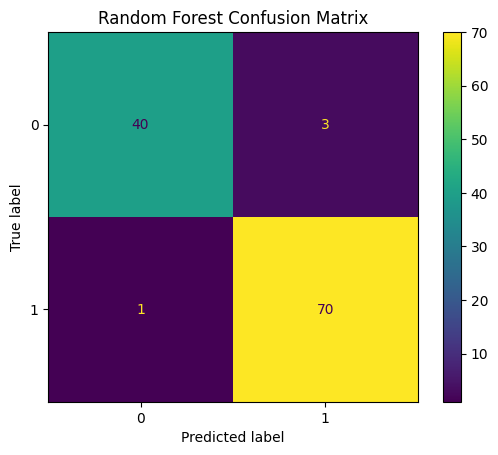

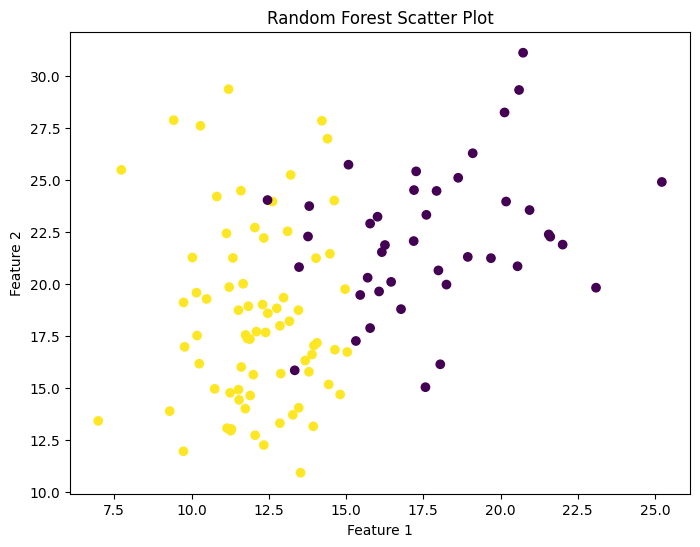

In [10]:
import matplotlib.pyplot as plt
from sklearn import svm, tree, neighbors, ensemble
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
    )

models = {
    "SVM": svm.SVC(),
    "Decision Tree": tree.DecisionTreeClassifier(random_state=42),
    "KNN": neighbors.KNeighborsClassifier(),
    "Random Forest": ensemble.RandomForestClassifier(random_state=42)
}

best_model = None
best_name = ""
best_accuracy = 0

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"{name} Accuracy: {accuracy:.4f}")

    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model = model
        best_name = name

print("\nBest Classifier:", best_name)
print("Best Accuracy:", round(best_accuracy, 4))

best_pred = best_model.predict(X_test)
cm = confusion_matrix(y_test, best_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title(f"{best_name} Confusion Matrix")

plt.savefig("wdbc_calssification_matrix.png")
plt.show()

plt.figure(figsize=(8, 6))

plt.scatter(
    X_test[:, 0],
    X_test[:, 1],
    c=best_pred
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title(f"{best_name} Scatter Plot")

plt.show()